In [16]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [17]:
import numpy as np
import matplotlib.pyplot as plt 
import copy
import time
from abc import ABC, abstractmethod
from typing import List, Tuple, Type
import qmcpy
from scipy.stats import norm 
from typing import Union, Tuple 
from joblib import Parallel, delayed, cpu_count
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel 
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [18]:
def generate_sobol_points(bounds: List[Tuple[float, float]] , num_points: int) -> np.ndarray:
    distribution = qmcpy.Sobol(dimension=len(bounds))
    pts01 = distribution.gen_samples(n=2 ** np.ceil(np.log2(num_points)))[:num_points]
    pts_scale = np.array([domain[1]-domain[0] for domain in bounds])
    pts_min = np.array([domain[0] for domain in bounds])
    return pts_min + pts_scale * pts01

In [19]:
class GaussianProcessModel(GaussianProcessRegressor):
    def __init__(self,**kwargs):
        super().__init__(**kwargs)
        self.is_fit = False

    def fit(self, X, y):
        super().fit(X, y)
        self.is_fit = True
        return self 
    
    def sample_single_point(self, x:np.ndarray, crn:Union[None, np.ndarray]=None):
        mean, std = self.predict(x.reshape(-1,1), return_std=True)
            
        if crn is None:
            return np.random.normal(mean, std, 1)
        else:
            return np.atleast_1d(mean + std*crn)

    def update(self, X_new: np.ndarray, y_new: np.ndarray):
        if not self.is_fit:
            raise RuntimeError("Model must be fit before calling update.")
        X_combined = np.concatenate((self.X_train_, X_new), axis=0)
        y_combined = np.concatenate((self.y_train_, y_new), axis=0)
        self.fit(X_combined, y_combined)
        return self 
    
    def min(self, bounds: List[Tuple[float, float]] , num_points: int=1000):
        points = generate_sobol_points(bounds, num_points)
        posterior_mean = self.predict(points, return_std=False)
        idx = np.argmin(posterior_mean)

        return points[[idx], : ], posterior_mean[idx]
        

In [20]:
class Policy(ABC):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]] = None
            ):
        self.model = model
        self.bounds = bounds

    @abstractmethod
    def evaluate(self, points: np.ndarray, **kwargs) -> Union[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        """ 
        points: (M, D)
        return: (M,) or ((M,), (M,))
        """
        raise NotImplementedError 
    
    def optimize(self, n_grid_points: int=1000) -> np.ndarray:
        """
        return: (D,)
        """
        points = generate_sobol_points(self.bounds, n_grid_points)
        vals = self.evaluate(points)
        idx = np.argmax(vals)

        return points[[idx], : ] 

In [21]:
class ExpectedImprovement(Policy):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]],
            ):
        super().__init__(model, bounds)

    def evaluate(self, points: np.ndarray) -> np.ndarray:
        """
        points: (M, D)
        return: (M,)
        """
        mu, std = self.model.predict(points, return_std=True)
        _, f_min = self.model.min(self.bounds)
        z = (f_min - mu)/np.fmax(std, 1e-8)
        cdf_z = norm.cdf(z)
        pdf_z = norm.pdf(z)

        return (std * np.fmax(0.0, z * cdf_z + pdf_z))

In [22]:
class MDPRollOut(Policy):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]],
                 horizon: int,
                 base_policy: Type[Policy], 
                 n_samples: int = int(1e2)
                ):
        super().__init__(model, bounds)
        self.horizon = horizon
        self.n_samples = n_samples
        self.base_policy = base_policy

    def evaluate(self, points: np.ndarray, **kwargs) -> Union[np.ndarray, 
                                                                      Tuple[np.ndarray, np.ndarray]]:
        return_std = kwargs.get("return_std", False)
        rewards = np.zeros((points.shape[0], self.n_samples))
        parallel = Parallel(n_jobs=cpu_count())
        for i in range(points.shape[0]):
            rewards[i,:] = parallel(delayed(self.draw_from_policy)(points[i].reshape(1, -1)) for _ in range(self.n_samples))
        if return_std:
            return rewards.mean(axis=1), rewards.std(axis=1)
        else:
            return rewards.mean(axis=1)

    # Execute policy once using sequential draws from GPs
    def draw_from_policy(self, x):
        reward = 0.0
        model = copy.deepcopy(self.model)
        acqf = self.base_policy(model, self.bounds)
        xi = copy.deepcopy(x)
        h = self.horizon

        while(True):
            np.random.seed(int(time.time()))
            fi = model.sample_single_point(xi)
            
            # get current reward from base policy
            ri = acqf.evaluate(xi).item()
            reward += ri
            h = h - 1
            if h <= 0:
                break
            
            # update the model and get next xi
            model = model.update(xi, fi.reshape(-1,1))
            xi = acqf.optimize()
        return reward.item() if isinstance(reward, np.ndarray) else reward

In [23]:
class ProbabilityImprovement(Policy):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]],
            ):
        super().__init__(model, bounds)

    def evaluate(self, points: np.ndarray, **kwargs) -> np.ndarray:
        """
        points: (M, D)
        return: (M,)
        """
        mu, std = self.model.predict(points, return_std=True)
        _, fmin = self.model.min(self.bounds)
        z = (fmin - mu)/std
        cdf_z = norm.cdf(z)
        
        return cdf_z

In [24]:
class MDPRollOutVarianceReduction(Policy):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]],
                 horizon: int,
                 base_policy: Type[Policy],
                 n_samples: int = int(1e2)
                ):
        super().__init__(model, bounds)
        self.horizon = horizon
        self.n_samples = n_samples
        self.base_policy = base_policy
        self.ei = ExpectedImprovement(model, bounds)
        self.pi = ProbabilityImprovement(model, bounds)

    def evaluate(self, points: np.ndarray, **kwargs) -> np.ndarray:
        rewards = np.zeros(points.shape[0])
        for i in range(points.shape[0]):
                r = self._evaluate(points[i].reshape(1, -1))
                rewards[i] = r.item() if isinstance(r, np.ndarray) else r
        return rewards
        
    def _evaluate(self, point : np.ndarray) -> np.ndarray:
        crns = self.low_discrepancy_points(self.n_samples, seed=1234)
        parallel = Parallel(n_jobs=cpu_count())
        rewards = parallel(delayed(self.draw_from_policy)(point, crn) for crn in crns)

        # Sum up samples to get estimate
        value_variates = np.sum(rewards) / self.n_samples

        # Remove effects of control variates
        ei_value = self.ei.evaluate(point)
        pi_value = self.pi.evaluate(point)
        value_corrected = value_variates + ei_value + pi_value

        return value_corrected        

    # Execute policy once using sequential draws from GPs
    def draw_from_policy(self, x:np.ndarray, crn:np.ndarray) -> np.ndarray:
        model = copy.deepcopy(self.model)
        xi = copy.deepcopy(x)
        h = self.horizon
        rewards = np.zeros(h)
        acqf = self.base_policy(model, self.bounds)

        for i in range(self.horizon):
            fi = model.sample_single_point(xi, crn[i])
            
            if i < self.horizon - 1:
                _, f_best = model.min(self.bounds)
                rewards[i] = self.reward(f_best, fi).item()
            else:
                rewards[i] = acqf.evaluate(xi).item()
            
            # update the model and get next xi
            model = model.update(xi, fi.reshape(-1,1))
            xi = acqf.optimize()
        
        r = np.sum(rewards)
        r -= rewards[0] # EI Control Variate
        if rewards[0] > 0:
            r -= 1
        return r
            
    def reward(self, f_best:np.ndarray, f_sample:np.ndarray)->np.ndarray:
        return np.max(f_best - f_sample, 0)
    
    def low_discrepancy_points(self, n_points:int, seed=1234):
        measure = qmcpy.Gaussian(qmcpy.Sobol(dimension=self.horizon, seed=seed))
        points = measure.gen_samples(n=2 ** np.ceil(np.log2(n_points)))[:n_points]
        points = np.nan_to_num(points)

        return points

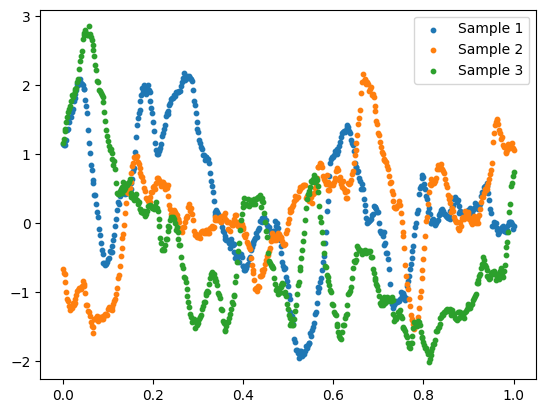

In [25]:
kernel = Matern(length_scale=0.05, nu=1.5, length_scale_bounds=(0.01, 1.0)) + \
      WhiteKernel(noise_level=1e-3 , noise_level_bounds=(1e-4, 1e-2))
prior = GaussianProcessRegressor(kernel=kernel)
X_test = np.atleast_2d(np.linspace(0, 1, 500)).T
prior_samples = prior.sample_y(X_test, n_samples=3, random_state=1234)
fig, ax = plt.subplots()
for i in range(prior_samples.shape[1]):
    ax.scatter(X_test, prior_samples[:, i], s = 10, label=f'Sample {i+1}')
ax.legend()
plt.show()

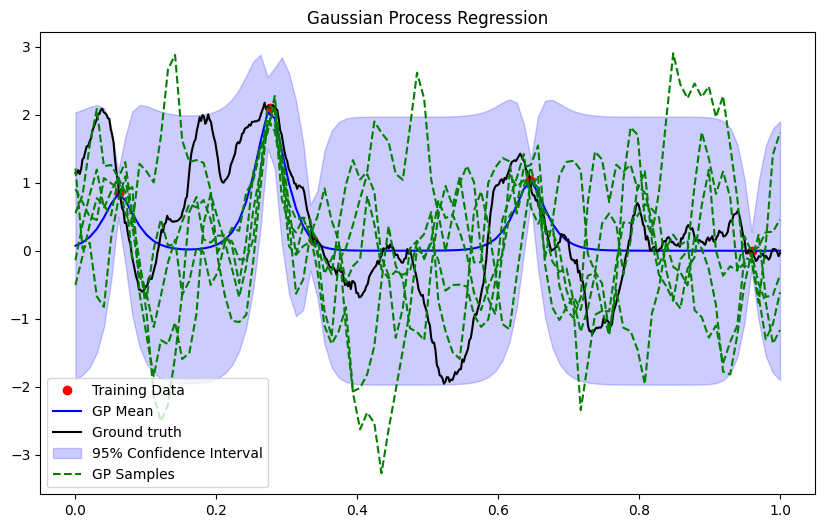

In [26]:
# Check GP model 
# bounds = [(0.0, 20.0)]
# train_x = np.random.uniform(low=bounds[0][0], high=bounds[0][1], size=(5, 1))
# train_y = np.sin(20*train_x) + 20*(train_x-0.3)**2 

# train_x = np.linspace(0.15, 0.85, 2)[:, None]
# train_y = np.array([0, 0])[:, None]
# bounds = [(0.0, 1.0)]

bounds = [(0.0, 1.0)]
ind = np.random.randint(X_test.shape[0], size=(5, 1))
train_x = X_test[ind].reshape(5,1)
train_y = prior_samples[ind,0].reshape(5,1)
ground_truth_y = prior_samples[:,0]

kernel = Matern(length_scale=0.25, 
                nu=1.5, 
                length_scale_bounds=(0.01, 1.0)
                ) + \
        WhiteKernel(noise_level=1e-3 , 
                    noise_level_bounds=(1e-4, 1e-2)
                )
params = {"kernel" : kernel, "n_restarts_optimizer":0}
gp = GaussianProcessModel(**params)
gp.fit(train_x, train_y)

test_x = np.linspace(bounds[0][0], bounds[0][1], 100).reshape(-1, 1)
mean, std = gp.predict(test_x, return_std=True)
samples = gp.sample_y(test_x, n_samples=5)
plt.figure(figsize=(10, 6))
plt.plot(train_x, train_y, 'ro', label='Training Data')
plt.plot(test_x, mean, 'b-', label='GP Mean')
plt.plot(X_test, ground_truth_y, "k-", label="Ground truth")
plt.fill_between(test_x.flatten(), 
                 mean - 1.96 * std, 
                 mean + 1.96 * std, 
                 color='blue', 
                 alpha=0.2, 
                 label='95% Confidence Interval'
            )
for i in range(samples.shape[1]):
    plt.plot(test_x, samples[:,i], "g--", label='GP Samples' if i==0 else None)
plt.legend()
plt.title('Gaussian Process Regression')
plt.show()

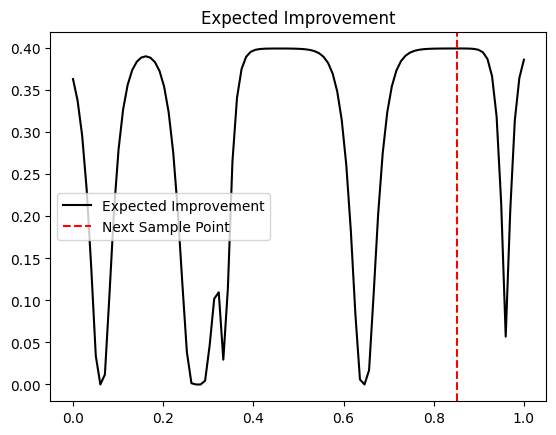

In [27]:
# Check EI policy
ei_policy = ExpectedImprovement(gp, bounds)
next_x = ei_policy.optimize()
ei_values = ei_policy.evaluate(test_x)
plt.figure()
plt.plot(test_x, ei_values, 'k-', label='Expected Improvement')
plt.axvline(next_x, color='r', linestyle='--', label='Next Sample Point')
plt.legend()
plt.title('Expected Improvement')
plt.show()

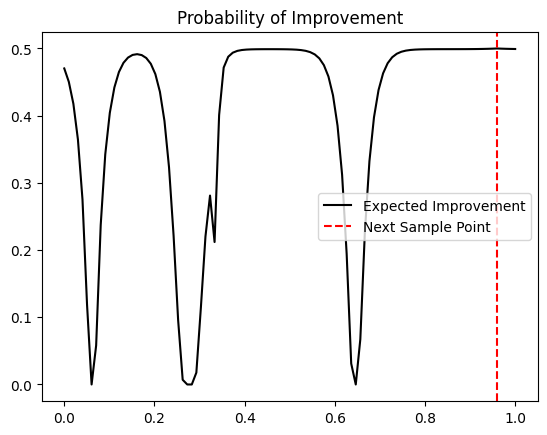

In [28]:
# Check PI policy
pi_policy = ProbabilityImprovement(gp, bounds)
next_x_pi = pi_policy.optimize()
pi_values = pi_policy.evaluate(test_x)
fig, ax = plt.subplots()
ax.plot(test_x, pi_values, 'k-', label='Expected Improvement')
ax.axvline(next_x_pi, color='r', linestyle='--', label='Next Sample Point')
plt.legend()
plt.title('Probability of Improvement')
plt.show()

In [29]:
# Check MDP Rollout policy
mdp_policy = MDPRollOut(gp, 
                        bounds, 
                        horizon=2, 
                        base_policy=ExpectedImprovement,
                        n_samples=128
                    )   
next_x_mdp = mdp_policy.optimize(n_grid_points=100)

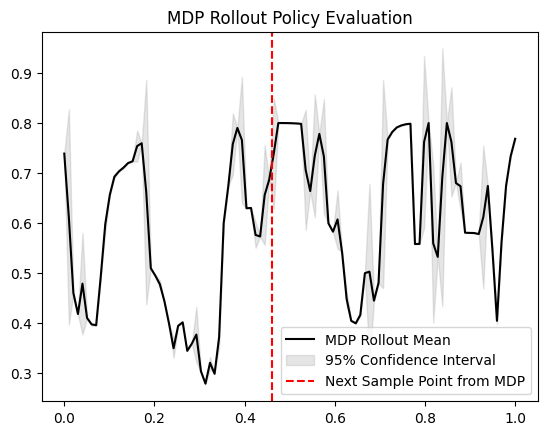

In [30]:
mdp_mean, mdp_std = mdp_policy.evaluate(test_x, return_std=True)
plt.figure()
plt.plot(test_x, mdp_mean, 'k-', label='MDP Rollout Mean')
plt.fill_between(test_x.flatten(), 
                 mdp_mean - 1.96 * mdp_std, 
                 mdp_mean + 1.96 * mdp_std, 
                 color='grey', 
                 alpha=0.2, 
                 label='95% Confidence Interval'
                )
plt.axvline(next_x_mdp, color='r', linestyle='--', label='Next Sample Point from MDP')
plt.legend()
plt.title('MDP Rollout Policy Evaluation')
plt.show()

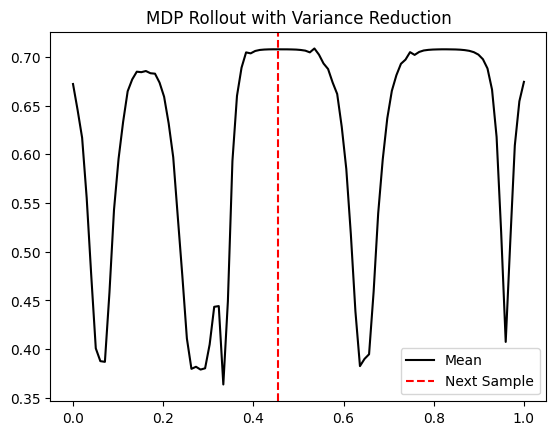

In [31]:
# Check MDP Rollout policy
mdp_vr_policy = MDPRollOutVarianceReduction(gp, 
                        bounds, 
                        horizon=2,
                        base_policy=ExpectedImprovement,
                        n_samples=128
                    )   
next_x_mdp_vr = mdp_vr_policy.optimize(n_grid_points=100)
mdp_vr_mean = mdp_vr_policy.evaluate(test_x)
plt.figure()
plt.plot(test_x, mdp_vr_mean, 'k-', label='Mean')
plt.axvline(next_x_mdp_vr, color='r', linestyle='--', label='Next Sample')
plt.legend()
plt.title('MDP Rollout with Variance Reduction')
plt.show()

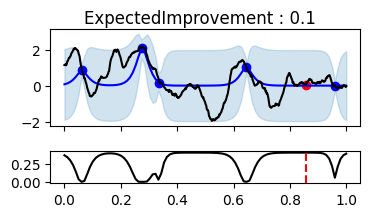

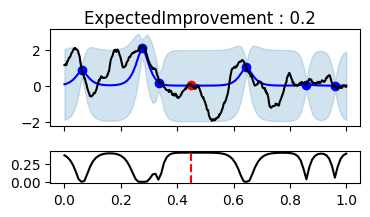

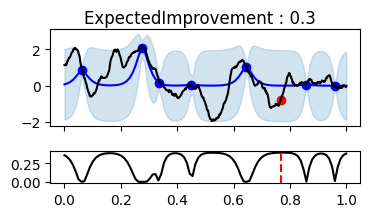

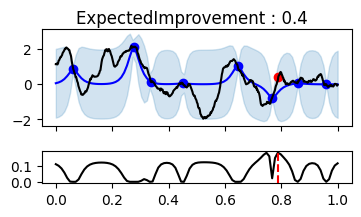

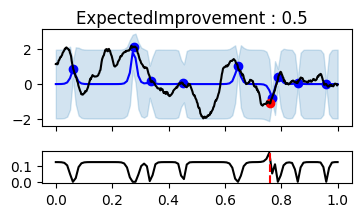

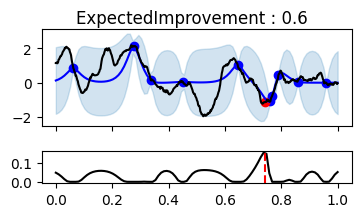

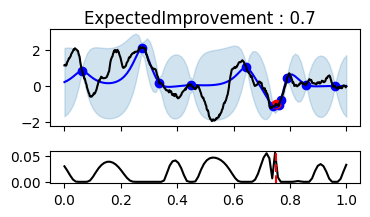

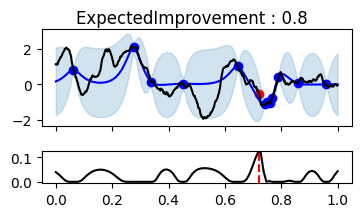

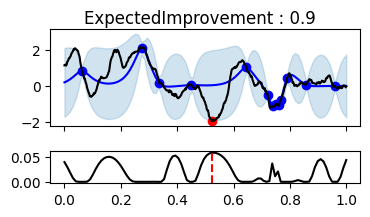

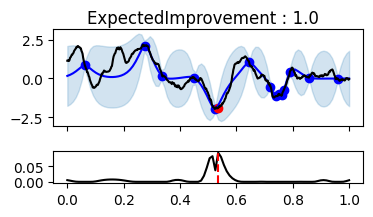

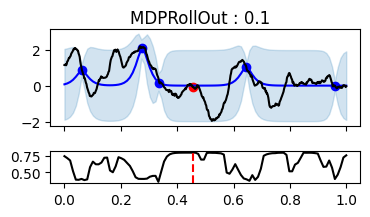

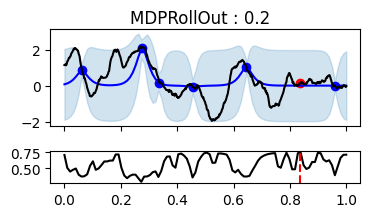

KeyboardInterrupt: 

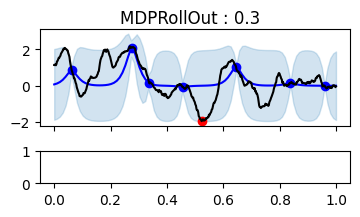

In [33]:
# Simple Bayesian Optimization
ei_policy = lambda model : ExpectedImprovement(model, bounds)
ei_mdp = lambda model : MDPRollOut(model, 
                                   bounds, 
                                   horizon=2, 
                                   base_policy=ExpectedImprovement,
                                   n_samples = 128
                                )
ei_mdp_vr = lambda model : MDPRollOutVarianceReduction(model, 
                                   bounds, 
                                   horizon=2, 
                                   base_policy=ExpectedImprovement,
                                   n_samples = 128
                                )

progress = np.zeros((3,10))
for i, p in enumerate([ei_policy, ei_mdp, ei_mdp_vr]):
    xi, yi = copy.deepcopy(train_x), copy.deepcopy(train_y)
    gp = GaussianProcessModel(**params)
    for j in range(10):
        gp.fit(xi, yi)
        _,best_y = gp.min(bounds)
        progress[i,j] = best_y
        policy = p(gp)
        next_x = policy.optimize(n_grid_points=100)
        fi = ground_truth_y[:,None][((X_test-next_x)**2).argmin()]

        xi = np.concatenate((xi, next_x), axis=0)
        yi = np.concatenate((yi, fi.reshape(-1,1)), axis=0)

        fig, axs = plt.subplots(2, 1, 
                                figsize=(2*2, 2), 
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True
                            )
        fig.subplots_adjust(hspace=0.4)
        fig.suptitle(f"{type(policy).__name__} : {(j+1)/10}")
        ax = axs[0]
        mean, std = gp.predict(test_x, return_std=True)
        ax.plot(xi[:-1], yi[:-1], 'bo', label='Training Data')
        ax.plot(xi[-1], yi[-1], 'ro', label='Next point')
        ax.plot(test_x, mean, 'b-', label='GP Mean')
        ax.plot(X_test, ground_truth_y, "k-", label="Ground truth")
        ax.fill_between(test_x.flatten(), 
                        mean - 1.96 * std, 
                        mean + 1.96 * std, 
                        color='tab:blue', 
                        alpha=0.2, 
                        label='95% Confidence Interval'
                    )
        
        ax = axs[1]
        values = policy.evaluate(test_x)
        ax.plot(test_x, values, 'k-',)
        ax.axvline(next_x, color="r", ls="--")

        plt.show()

In [ ]:
fig, ax = plt.subplots()
ax.plot(np.arange(progress.shape[1]), progress[0,:],"o-", label="ExpectedImprovement")
ax.plot(np.arange(progress.shape[1]), progress[1,:],"o-", label="MDPRollOut")
ax.plot(np.arange(progress.shape[1]), progress[2,:],"o-", label="MDPRollOutVarianceReduction")
ax.axhline(min(ground_truth_y), color="k", ls='--', label="Global Minimum")
ax.set_xlabel("Iterations")
ax.set_ylabel("Optimum value")
ax.legend()
plt.show()

NameError: name 'plt' is not defined